# Pipeline Output Explorer
Visualisasi hasil Bronze → Silver → Gold → Quarantine

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = Path('data/output')

def read_parquet(layer: str) -> pd.DataFrame:
    path = OUTPUT_DIR / layer
    if not path.exists():
        print(f'⚠️  {layer}/ not found — run pipeline first')
        return pd.DataFrame()
    return pd.read_parquet(path)

bronze     = read_parquet('bronze')
silver     = read_parquet('silver')
gold       = read_parquet('gold')
quarantine = read_parquet('quarantine')

print('Layers loaded:')
for name, df in [('bronze', bronze), ('silver', silver), ('gold', gold), ('quarantine', quarantine)]:
    print(f'  {name:<12} {len(df):>4} rows  |  cols: {list(df.columns)}')

Layers loaded:
  bronze         11 rows  |  cols: ['event_id', 'user_id', 'event_type', 'value', 'event_ts', 'event_date']
  silver         11 rows  |  cols: ['user_id', 'event_id', 'event_type', 'value', 'event_ts', 'country', 'signup_date', 'is_purchase', 'days_since_signup', 'event_date']
  gold            6 rows  |  cols: ['country', 'total_events', 'total_value', 'total_purchases', 'unique_users', 'event_date']
  quarantine      5 rows  |  cols: ['event_id', 'user_id', 'event_type', 'event_ts', 'value', '_reject_reason', '_quarantine_ts']


## Row count per layer

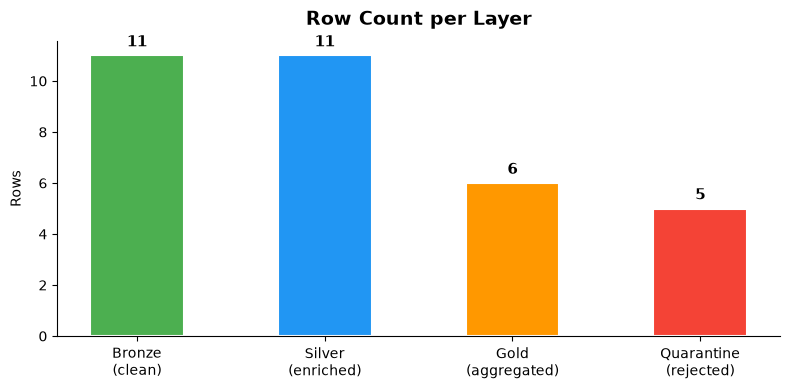

In [4]:
counts = {
    'Bronze\n(clean)': len(bronze),
    'Silver\n(enriched)': len(silver),
    'Gold\n(aggregated)': len(gold),
    'Quarantine\n(rejected)': len(quarantine),
}

colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.keys(), counts.values(), color=colors, width=0.5, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=11, fontweight='bold')
ax.set_title('Row Count per Layer', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Rows')
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Bronze — Clean Events

In [5]:
print(f'Shape: {bronze.shape}')
bronze.head(20)

Shape: (11, 6)


,event_id,user_id,event_type,value,event_ts,event_date
0,e13,u2,VIEW,1.0,2024-12-31 16:50:00,2024-12-31
1,e1,u1,CLICK,3.0,2025-01-01 03:00:00,2025-01-01
2,e2,u2,VIEW,0.0,2025-01-01 03:05:00,2025-01-01
3,e3,u1,PURCHASE,25.0,2025-01-01 03:10:00,2025-01-01
4,e5,u3,CLICK,1.0,2025-01-01 04:00:00,2025-01-01
5,e6,u1,CLICK,2.0,2025-01-01 04:05:00,2025-01-01
6,e8,u2,PURCHASE,30.0,2025-01-01 04:30:00,2025-01-01
7,e9,u1,VIEW,0.0,2025-01-01 05:00:00,2025-01-01
8,e10,u1,CLICK,1.0,2025-01-02 02:00:00,2025-01-02
9,e11,u2,VIEW,2.0,2025-01-02 02:10:00,2025-01-02


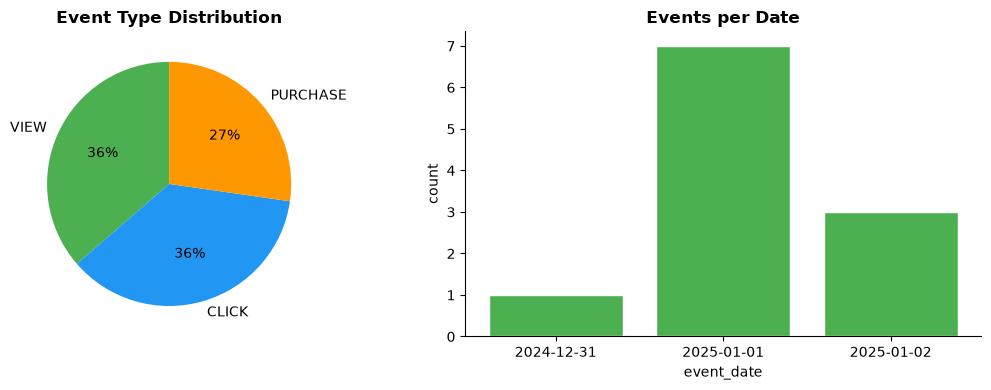

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# event_type distribution
et_counts = bronze['event_type'].value_counts()
axes[0].pie(et_counts, labels=et_counts.index, autopct='%1.0f%%',
            colors=['#4CAF50', '#2196F3', '#FF9800'], startangle=90)
axes[0].set_title('Event Type Distribution', fontweight='bold')

# events per date
if 'event_date' in bronze.columns:
    date_counts = bronze.groupby('event_date').size()
    axes[1].bar(date_counts.index.astype(str), date_counts.values, color='#4CAF50', edgecolor='white')
    axes[1].set_title('Events per Date', fontweight='bold')
    axes[1].set_xlabel('event_date')
    axes[1].set_ylabel('count')
    axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Quarantine — Rejected Events

In [7]:
print(f'Shape: {quarantine.shape}')
quarantine.head(20)

Shape: (5, 7)


,event_id,user_id,event_type,event_ts,value,_reject_reason,_quarantine_ts
0,e4,NaN,CLICK,invalid_ts,1.0,null_or_empty_user_id,2026-06-19 17:15:18.949968
1,e7,u2,VIEW,NaN,4.0,invalid_or_null_event_ts,2026-06-19 17:15:18.949968
2,e14,,CLICK,2025-01-02T10:00:00Z,1.0,null_or_empty_user_id,2026-06-19 17:15:18.949968
3,e15,u1,NaN,2025-01-02T10:05:00Z,3.0,invalid_event_type,2026-06-19 17:15:18.949968
4,e16,u1,PURCHASE,2025-13-01T00:00:00Z,5.0,invalid_or_null_event_ts,2026-06-19 17:15:18.949968


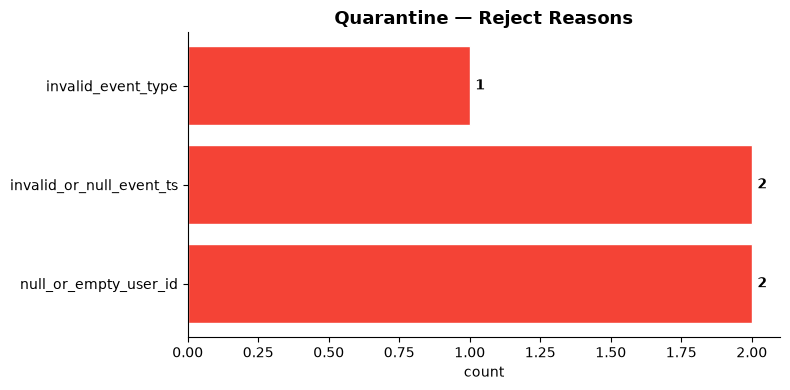

In [8]:
if len(quarantine) > 0 and '_reject_reason' in quarantine.columns:
    reason_counts = quarantine['_reject_reason'].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(reason_counts.index, reason_counts.values, color='#F44336', edgecolor='white')
    ax.bar_label(bars, fmt='%d', padding=4, fontweight='bold')
    ax.set_title('Quarantine — Reject Reasons', fontsize=13, fontweight='bold')
    ax.set_xlabel('count')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print('No quarantine data or _reject_reason column missing.')

## Silver — Enriched Events

In [9]:
print(f'Shape: {silver.shape}')
silver.head(20)

Shape: (11, 10)


,user_id,event_id,event_type,value,event_ts,country,signup_date,is_purchase,days_since_signup,event_date
0,u2,e13,VIEW,1.0,2024-12-31 16:50:00,US,2024-12-15,False,16.0,2024-12-31
1,u1,e1,CLICK,3.0,2025-01-01 03:00:00,ID,2024-12-01,False,31.0,2025-01-01
2,u2,e2,VIEW,0.0,2025-01-01 03:05:00,US,2024-12-15,False,17.0,2025-01-01
3,u1,e3,PURCHASE,25.0,2025-01-01 03:10:00,ID,2024-12-01,True,31.0,2025-01-01
4,u3,e5,CLICK,1.0,2025-01-01 04:00:00,SG,None,False,NaN,2025-01-01
5,u1,e6,CLICK,2.0,2025-01-01 04:05:00,ID,2024-12-01,False,31.0,2025-01-01
6,u2,e8,PURCHASE,30.0,2025-01-01 04:30:00,US,2024-12-15,True,17.0,2025-01-01
7,u1,e9,VIEW,0.0,2025-01-01 05:00:00,ID,2024-12-01,False,31.0,2025-01-01
8,u1,e10,CLICK,1.0,2025-01-02 02:00:00,ID,2024-12-01,False,32.0,2025-01-02
9,u2,e11,VIEW,2.0,2025-01-02 02:10:00,US,2024-12-15,False,18.0,2025-01-02


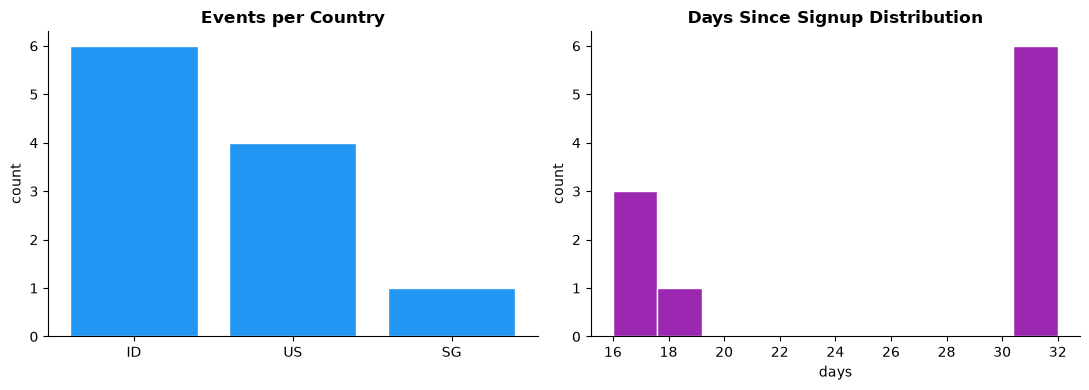

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# events per country
if 'country' in silver.columns:
    country_counts = silver['country'].value_counts()
    axes[0].bar(country_counts.index, country_counts.values, color='#2196F3', edgecolor='white')
    axes[0].set_title('Events per Country', fontweight='bold')
    axes[0].set_ylabel('count')
    axes[0].spines[['top', 'right']].set_visible(False)

# days_since_signup distribution
if 'days_since_signup' in silver.columns:
    dss = silver['days_since_signup'].dropna()
    axes[1].hist(dss, bins=10, color='#9C27B0', edgecolor='white')
    axes[1].set_title('Days Since Signup Distribution', fontweight='bold')
    axes[1].set_xlabel('days')
    axes[1].set_ylabel('count')
    axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Gold — Daily Aggregates

In [11]:
print(f'Shape: {gold.shape}')
gold.sort_values(['event_date', 'country'])

Shape: (6, 6)


,country,total_events,total_value,total_purchases,unique_users,event_date
0,US,1,1.0,0,1,2024-12-31
1,ID,4,30.0,1,1,2025-01-01
2,SG,1,1.0,0,1,2025-01-01
3,US,2,30.0,1,1,2025-01-01
4,ID,2,21.0,1,1,2025-01-02
5,US,1,2.0,0,1,2025-01-02


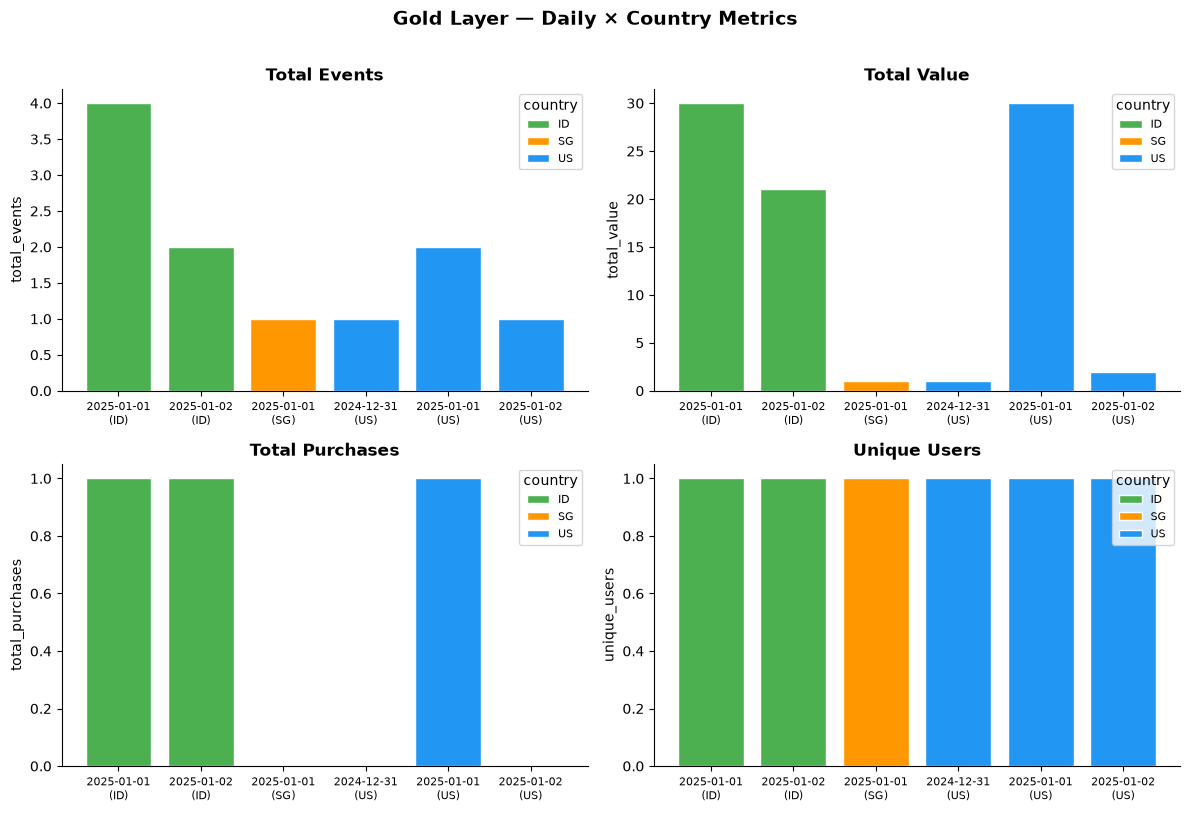

In [12]:
if len(gold) > 0:
    gold['event_date'] = gold['event_date'].astype(str)
    metrics = ['total_events', 'total_value', 'total_purchases', 'unique_users']
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    colors_map = {'ID': '#4CAF50', 'US': '#2196F3', 'SG': '#FF9800', 'UNKNOWN': '#9E9E9E'}

    for i, metric in enumerate(metrics):
        ax = axes[i]
        for country, grp in gold.groupby('country'):
            color = colors_map.get(country, '#607D8B')
            ax.bar(
                [f"{d}\n({country})" for d in grp['event_date']],
                grp[metric],
                label=country, color=color, edgecolor='white'
            )
        ax.set_title(metric.replace('_', ' ').title(), fontweight='bold')
        ax.set_ylabel(metric)
        ax.legend(title='country', fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='x', labelsize=8)

    plt.suptitle('Gold Layer — Daily × Country Metrics', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()